# Task-1

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [3]:
x = sp.symbols('x')

# Functions

f = x**4
g = 3*x**2 + 2*x - 7
h = 1/x

# Exact derivatives

df = sp.diff(f, x)
dg = sp.diff(g, x)
dh = sp.diff(h, x)

print("f'(x) =", df)
print("g'(x) =", dg)
print("h'(x) =", dh)

print("\nExact derivatives at x=2:")
print("f'(2) =", df.subs(x, 2))
print("g'(2) =", dg.subs(x, 2))
print("h'(2) =", dh.subs(x, 2))

# Numerical derivative

def numerical_derivative(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)

def f_func(x):
    return x**4

def g_func(x):
    return 3*x**2 + 2*x - 7

def h_func(x):
    return 1/x

print("\nNumerical derivatives at x=2:")
print("f numerical =", numerical_derivative(f_func, 2))
print("g numerical =", numerical_derivative(g_func, 2))
print("h numerical =", numerical_derivative(h_func, 2))

f'(x) = 4*x**3
g'(x) = 6*x + 2
h'(x) = -1/x**2

Exact derivatives at x=2:
f'(2) = 32
g'(2) = 14
h'(2) = -1/4

Numerical derivatives at x=2:
f numerical = 32.000000001009
g numerical = 14.000000000002897
h numerical = -0.2500000000099645


# Task-2

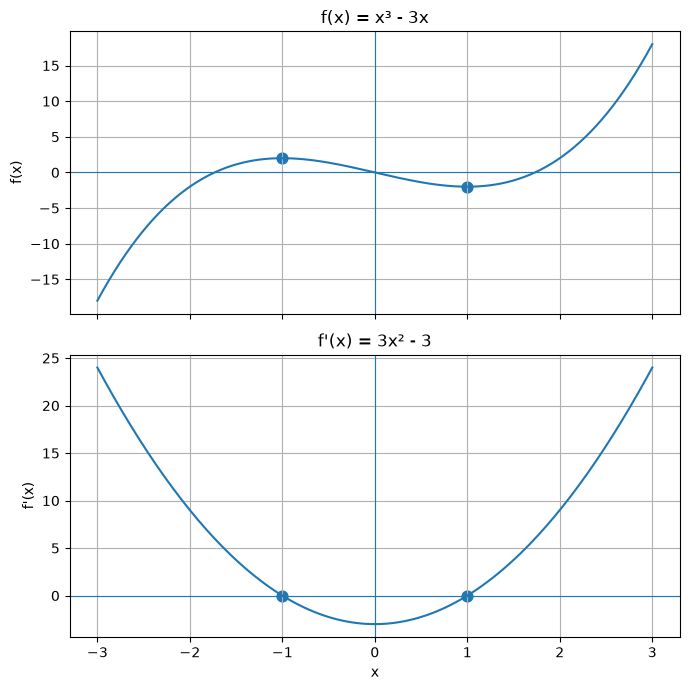

In [4]:
# x values
x = np.linspace(-3, 3, 200)

# Function
f = x**3 - 3*x

# Derivative
df = 3*x**2 - 3

# Create two panels
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# Top: original function

axes[0].plot(x, f)
axes[0].axhline(0, linewidth=0.8)
axes[0].axvline(0, linewidth=0.8)

axes[0].scatter([-1, 1], [2, -2], s=60)

axes[0].set_title("f(x) = x³ - 3x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)

# -------------------------
# Bottom: derivative
# -------------------------
axes[1].plot(x, df)
axes[1].axhline(0, linewidth=0.8)
axes[1].axvline(0, linewidth=0.8)

# Zero-crossings
axes[1].scatter([-1, 1], [0, 0], s=60)

axes[1].set_title("f'(x) = 3x² - 3")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f'(x)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Task-3

Function:
f(x, y) = x**2 + x*y + 2*y**2

Partial derivatives:
df/dx = 2*x + y
df/dy = x + 4*y

Gradient at three points:
At (1, 1): [3 5]
At (-1, -1): [-3 -5]
At (2, -1): [ 3 -2]

Uphill / downhill check:

Point: (1, 1)
Gradient: [3 5]
Current value: 4
Value along gradient: 4.3474
Value against gradient: 3.6673999999999998
 Moving along gradient increases the function
 Moving against gradient decreases the function

Point: (-1, -1)
Gradient: [-3 -5]
Current value: 4
Value along gradient: 4.3474
Value against gradient: 3.6673999999999998
 Moving along gradient increases the function
 Moving against gradient decreases the function

Point: (2, -1)
Gradient: [ 3 -2]
Current value: 4
Value along gradient: 4.131099999999999
Value against gradient: 3.8711
 Moving along gradient increases the function
 Moving against gradient decreases the function

Minimum:
The minimum occurs at (0, 0)
Gradient at (0, 0): [0 0]


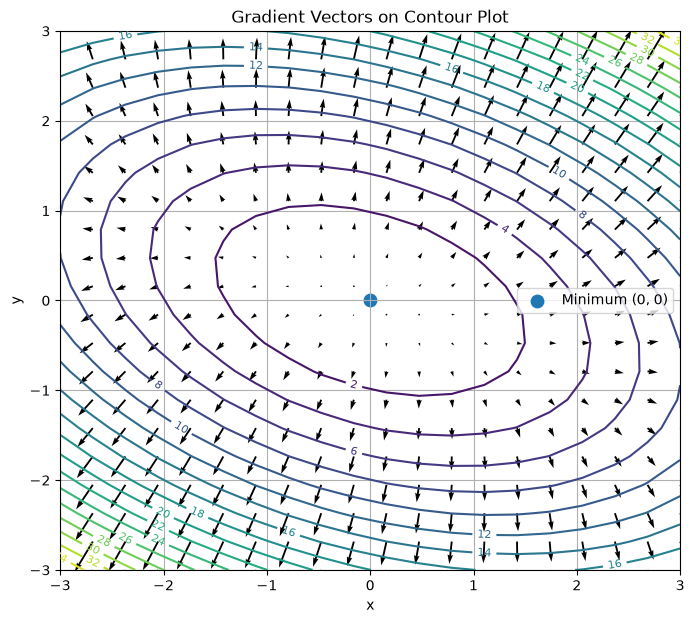

In [5]:
# 1. Define the function using SymPy


x, y = sp.symbols('x y')

f = x**2 + 2*y**2 + x*y

print("Function:")
print("f(x, y) =", f)


# 2. Partial derivatives using SymPy

df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

print("\nPartial derivatives:")
print("df/dx =", df_dx)
print("df/dy =", df_dy)


# 3. Gradient function

def gradient(px, py):
    return np.array([
        2 * px + py,
        px + 4 * py
    ])


# 4. Function in Python

def function(px, py):
    return px**2 + 2 * py**2 + px * py


# 5. Evaluate gradient at three points

points = [
    (1, 1),
    (-1, -1),
    (2, -1)
]

print("\nGradient at three points:")

for px, py in points:
    grad = gradient(px, py)

    print(f"At ({px}, {py}): {grad}")


# 6. Check that gradient points uphill

epsilon = 0.01

print("\nUphill / downhill check:")

for px, py in points:

    grad = gradient(px, py)

    current_value = function(px, py)

    # Move in gradient direction
    uphill_value = function(
        px + epsilon * grad[0],
        py + epsilon * grad[1]
    )

    # Move opposite to gradient
    downhill_value = function(
        px - epsilon * grad[0],
        py - epsilon * grad[1]
    )

    print(f"\nPoint: ({px}, {py})")
    print("Gradient:", grad)
    print("Current value:", current_value)
    print("Value along gradient:", uphill_value)
    print("Value against gradient:", downhill_value)

    if uphill_value > current_value:
        print(" Moving along gradient increases the function")

    if downhill_value < current_value:
        print(" Moving against gradient decreases the function")


# 7. Find the minimum

print("\nMinimum:")
print("The minimum occurs at (0, 0)")
print("Gradient at (0, 0):", gradient(0, 0))


# 8. Create a grid for contour plot

x_values = np.linspace(-3, 3, 20)
y_values = np.linspace(-3, 3, 20)

X, Y = np.meshgrid(x_values, y_values)


# 9. Calculate function values

Z = X**2 + 2 * Y**2 + X * Y


# 10. Calculate gradient components

U = 2 * X + Y
V = X + 4 * Y


# 11. Contour plot + gradient arrows

plt.figure(figsize=(8, 7))

# Contours
contours = plt.contour(X, Y, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

# Gradient arrows
plt.quiver(X, Y, U, V)

# Minimum point
plt.scatter(0, 0, s=80, label="Minimum (0, 0)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Vectors on Contour Plot")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
# PART 1: f(x) = (3x + 1)^5

x = sp.symbols('x')

f = (3*x + 1)**5

# SymPy derivative
derivative = sp.diff(f, x)

print("Function:")
print(f)

print("\nDerivative using SymPy:")
print(derivative)

# Numerical derivative
def f_value(x):
    return (3*x + 1)**5


def numerical_derivative(x, h=1e-5):
    return (f_value(x + h) - f_value(x)) / h


exact_derivative = sp.lambdify(x, derivative, "numpy")
print("\nNumerical verification:")

for value in [0, 1, 2]:
    numerical = numerical_derivative(value)
    exact = exact_derivative(value)

    print(f"x = {value}")
    print("Numecal:", numerical)
    print("Exact:", exact)
    print()


# PART 2: f(x) = sin((2x + 1)^2)

f2 = sp.sin((2*x + 1)**2)

# SymPy derivative
derivative2 = sp.diff(f2, x)

print("Three-layer function:")
print(f2)

print("\nDerivative using SymPy:")
print(derivative2)

# Numerical verification

def f2_value(x):
    return np.sin((2*x + 1)**2)


def numerical_derivative_f2(x, h=1e-5):
    return (f2_value(x + h) - f2_value(x)) / h


exact_derivative_f2 = sp.lambdify(x, derivative2, "numpy")

print("\nThree-layer numerical verification:")

for value in [0, 1, 2]:
    numerical = numerical_derivative_f2(value)
    exact = exact_derivative_f2(value)

    print(f"x = {value}")
    print("Numerical:", numerical)
    print("Exact:", exact)
    print()


# PART 3: Compare different h values

x_value = 1

h_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

exact = exact_derivative_f2(x_value)

print("Error for different h values:")

for h in h_values:
    numerical = numerical_derivative_f2(x_value, h)
    error = abs(numerical - exact)

    print(f"h = {h:.0e}, error = {error:.10f}")

Function:
(3*x + 1)**5

Derivative using SymPy:
15*(3*x + 1)**4

Numerical verification:
x = 0
Numecal: 15.000900026995721
Exact: 15

x = 1
Numecal: 3840.0576005187754
Exact: 3840

x = 2
Numecal: 36015.30870218994
Exact: 36015

Three-layer function:
sin((2*x + 1)**2)

Derivative using SymPy:
(8*x + 4)*cos((2*x + 1)**2)

Three-layer numerical verification:
x = 0
Numerical: 2.1611635159568543
Exact: 2.161209223472559

x = 1
Numerical: -10.933896288950471
Exact: -10.933563142616123

x = 2
Numerical: 19.824360457734723
Exact: 19.82405623726947

Error for different h values:
h = 1e-01, error = 0.4664004133
h = 1e-02, error = 0.3083066889
h = 1e-03, error = 0.0330738143
h = 1e-04, error = 0.0033292784
h = 1e-05, error = 0.0003331463
h = 1e-06, error = 0.0000333154
h = 1e-07, error = 0.0000033379
